# **Züri wie neu Waste per Resident in the Neighbourhoods of Zürich**

Author: Tim Berger  
Date: 22.5.2026
<br>
<br>

### Introduction
The Zürich wie neu website allows the residents of Zürich to report damage and defects of the infrastructure of the city.  
Reports are sorted in different categories, such as waste or graffiti.  
Illegal deposited waste and littering in the "waste/collection site" category is reported the most (see category analysis notebook).  
As seen in the heatmap, the number of reports is, generally speaking, higher in the centre of Zürich, compared to the outer regions.  
At the same time, also more people live in the city center compared to the outer regions.   
Therefore this analysis aims to compare the heatmap with the number of waste reports per neighbourhood in the city of Zürich
<br>
<br>

### Research Question: 
Do the waste report hotspots on the heatmap correlate with the reports per resident for the neighbourhoods of zurich?
<br>
<br>

### Requirements
see README file
<br>
<br>

### **Import Required Packages and Scripts**

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import datetime as dt
import contextily as ctx
import cmcrameri.cm as cmc
from matplotlib_scalebar.scalebar import ScaleBar

import notebook_utils

### **Load data**

In [2]:
# the notebook_utils file contains the functions to load the required data
# if a dataset failed to load, the corresponding url should be checked
# the source and explanation of the url can be found in the README file.

url_zwn = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Zueri_wie_neu?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=zwn_meldungen_p"
url_neighbourhoods = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statistische_quartiere_v"
url_neighbourhood_labels = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statistische_quartiere_b_p"
url_population = 'https://data.stadt-zuerich.ch/api/3/action/datastore_search?resource_id=9f9e2f24-96a7-4542-843c-52d44a904110&limit=10000'

zwn_gdf_raw = notebook_utils.import_geografic_data(url_zwn)
neighbourhoods_gdf_raw = notebook_utils.import_geografic_data(url_neighbourhoods)
population_df_raw = notebook_utils.import_data(url_population)
neighbourhood_labels_gdf_raw = notebook_utils.import_geografic_data(url_neighbourhood_labels)


data loaded successfully
data loaded successfully
data loaded successfully
data loaded successfully


### **Clean and Filter the Data**

- clean population data

In [3]:
## filter population for the newest year

# display the current year
current_year = int(dt.date.today().year)

#filter dataframe for the newest year
population_df = population_df_raw[population_df_raw["StichtagDatJahr"] == str(current_year-1)].copy()

#clean the population data
#drop the columns not needed
population_df= population_df.drop(columns=["StichtagDatJahr", "QuarSort", "_id"])

#convert numbers to integer
population_df["AnzBestWir"] = population_df["AnzBestWir"].astype(int)

#rename the columns
population_df = population_df.rename(columns={"AnzBestWir": "population", "QuarLang": "qname"})

# check if everything worked and if there are NA values
population_df.info()



<class 'pandas.DataFrame'>
Index: 34 entries, 0 to 2729
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   qname       34 non-null     str  
 1   population  34 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.1 KB


- clean züri wie neu data

In [4]:
# filter the züri wie neu data for waste
zwn_waste_gdf = zwn_gdf_raw[zwn_gdf_raw["service_name"]=="Abfall/Sammelstelle"].copy()

# filter for the required columns
zwn_waste_gdf = zwn_waste_gdf[["service_request_id", "title", "geometry"]]

# check if everything worked and if there are NA values
zwn_waste_gdf.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 27670 entries, 4 to 73342
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   service_request_id  27670 non-null  str     
 1   title               27670 non-null  str     
 2   geometry            27670 non-null  geometry
dtypes: geometry(1), str(2)
memory usage: 1.3 MB


- clean neighbourhood data

In [5]:
#filter neighbourhoods data for required columns 
neighbourhoods_gdf = neighbourhoods_gdf_raw[["qname", "qnr", "geometry"]]

# filter the neighbourhood label data for required columns
neighbourhood_labels_gdf = neighbourhood_labels_gdf_raw[["name", "geometry"]].copy()

# check if everything worked, and if there are NA values
neighbourhoods_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   qname     34 non-null     str     
 1   qnr       34 non-null     int32   
 2   geometry  34 non-null     geometry
dtypes: geometry(1), int32(1), str(1)
memory usage: 1.1 KB


### **Join and Merge Data Together**

In [6]:

#join the trash points to the neighbourhoods

waste_with_neighbourhoods_df = gpd.sjoin(zwn_waste_gdf, 
                                          neighbourhoods_gdf,
                                          how="inner",
                                          predicate="within")


#count the number of waste per neighbourhood and safe it as a dataframe waste_income_df
waste_pop_df = waste_with_neighbourhoods_df[["qname"]].value_counts().to_frame()

#rename the dataframe
waste_pop_df = waste_pop_df.rename(columns={"count":"count_waste"})

In [7]:
# merge the population to the neighbourhoods

waste_pop_df = pd.merge(right=waste_pop_df, 
                                        left=population_df,
                                        left_on="qname",
                                        right_on="qname")
waste_pop_df = waste_pop_df.sort_values(by="population", ascending=True)
waste_pop_df = waste_pop_df.set_index("qname")

In [8]:
# merge the population and waste to the geometry and calculate the pop density and waste per resident
waste_pop_gdf = pd.merge(left=neighbourhoods_gdf, 
                                        right=waste_pop_df,
                                        left_on="qname",
                                        right_on="qname")

# calculate the population density
waste_pop_gdf["population_density"] = round(1000 *waste_pop_gdf["population"]/waste_pop_gdf.geometry.area,2)

# normalize the waste per 100 person
waste_pop_gdf["waste_per_pop"] = round(100* waste_pop_gdf["count_waste"]/waste_pop_gdf["population"],2) 

# normalize the waste per area
waste_pop_gdf["waste_per_area"] = round(1000000* waste_pop_gdf["count_waste"]/waste_pop_gdf.geometry.area)

# sort neighbourhoods by population density
waste_pop_gdf = waste_pop_gdf.sort_values(by= "waste_per_area", ascending=True)

# check if everything worked and how the data looks
waste_pop_gdf.head(5)



,qname,qnr,geometry,population,count_waste,population_density,waste_per_pop,waste_per_area
1,Witikon,74,"POLYGON ((2685858.618 1246502.677, 2685860.724...",11984,269,2.43,2.24,55.0
31,Friesenberg,33,"POLYGON ((2678931.42 1245766.698, 2678940.152 ...",11226,349,2.12,3.11,66.0
7,Leimbach,23,"POLYGON ((2680272.541 1242790.882, 2680279.745...",6316,263,2.16,4.16,90.0
14,Hottingen,72,"POLYGON ((2683859.976 1246754.268, 2683865.226...",11620,532,2.30,4.58,105.0
18,Affoltern,111,"POLYGON ((2678898.276 1253662.376, 2678898.573...",27439,793,4.54,2.89,131.0


### **Plot Data**

c:\Users\timbe\miniconda3\envs\sds210\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


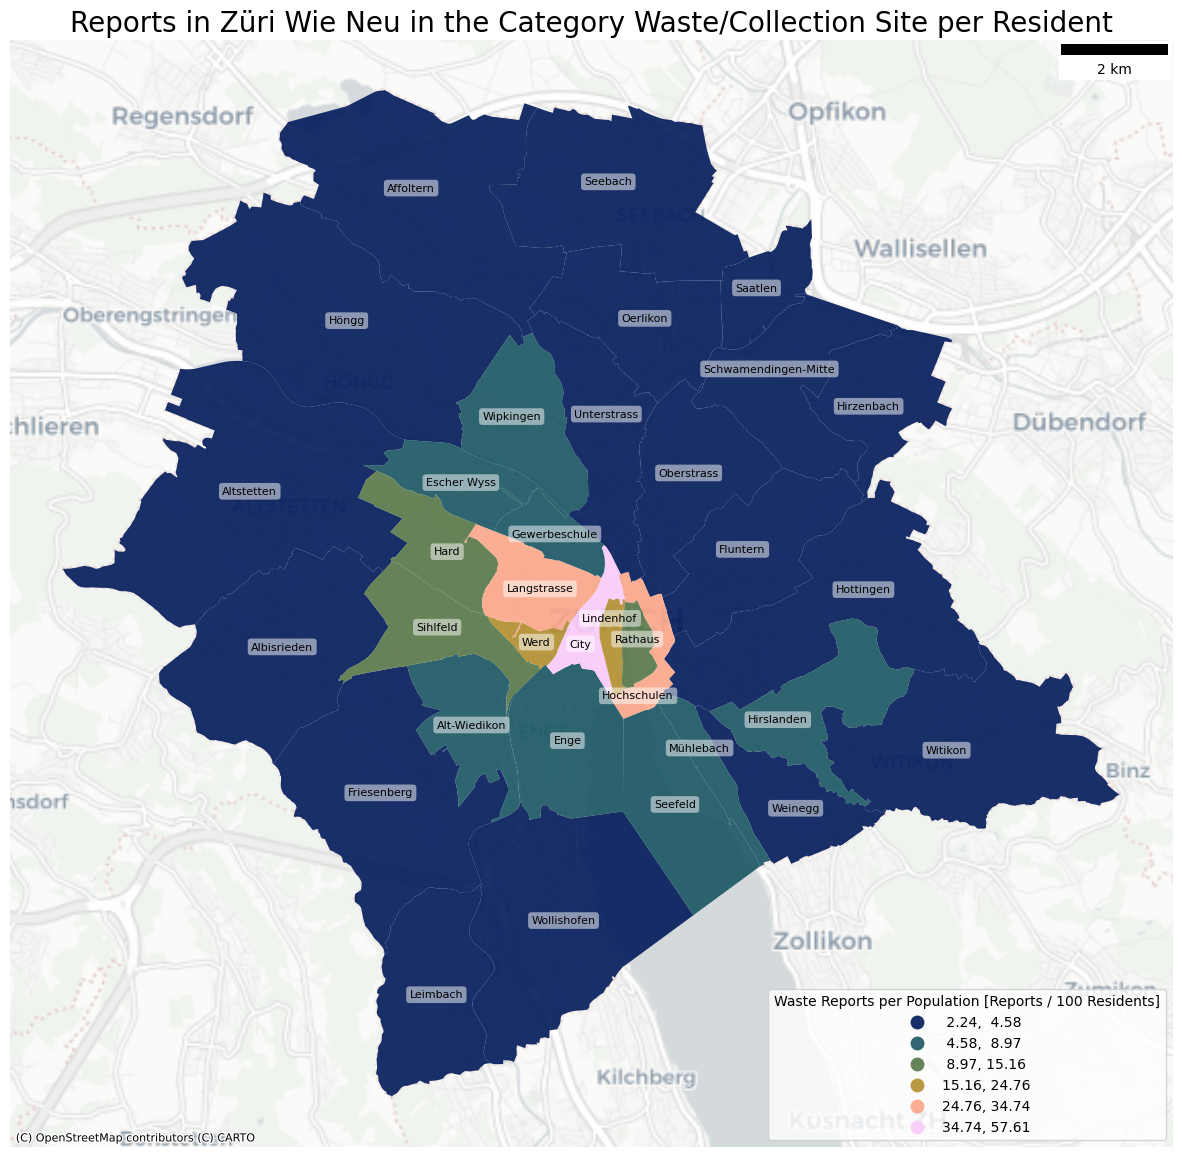

In [13]:
fig, ax = plt.subplots( figsize= (15,15))

#change to web mercator to be able to plot the contextily tiles on top
waste_pop_gdf.to_crs(epsg=3857).plot(ax=ax, 
                                     column= "waste_per_pop", 
                                     scheme="natural_breaks", 
                                     k=6, 
                                     legend=True,
                                     legend_kwds={"title": "Waste Reports per Population [Reports / 100 Residents]", "loc": "lower right"}, 
                                     alpha=0.9,
                                     cmap= cmc.batlow)

# hide the x and y axes lines, ticks, and coordinate numbers
ax.axis("off")

# set a title
ax.set_title("Reports in Züri Wie Neu in the Category Waste/Collection Site per Resident", size=20)

# add basemap
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Positron)

# add the labels
for idx, row in neighbourhood_labels_gdf.to_crs(epsg=3857).iterrows():
    x, y = row.geometry.x, row.geometry.y

    # change the lindenhof label y coordinate
    if row['name'] == 'Lindenhof':
        y += 200
    
    ax.annotate(
    text=row['name'],
    xy=(x, y),
    fontsize=8,
    ha='center',
    color= "black",
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5, edgecolor='none')
)

# add a scalebar
scalebar = ScaleBar(1)
ax.add_artist(scalebar)

# save figure in the figures folder
fig.savefig("../figures/waste_population_rate_map.png", dpi=300, bbox_inches="tight")

plt.show()

### **Results**
Compared to the heatmap, the city neighbourhood has the largest number of waste reports per population. Apart from this the choropleth map does align quite well with the heatmap, the neighbourhoods around the crossing of the Badener- and Seebahnstrasse (Sihlfeld, Hard, Langstrasse, Werd) do have higher values than the suburban neighbourhoods. So do the central neighbourhoods Lindenhof, Rathaus and Hochschulen.